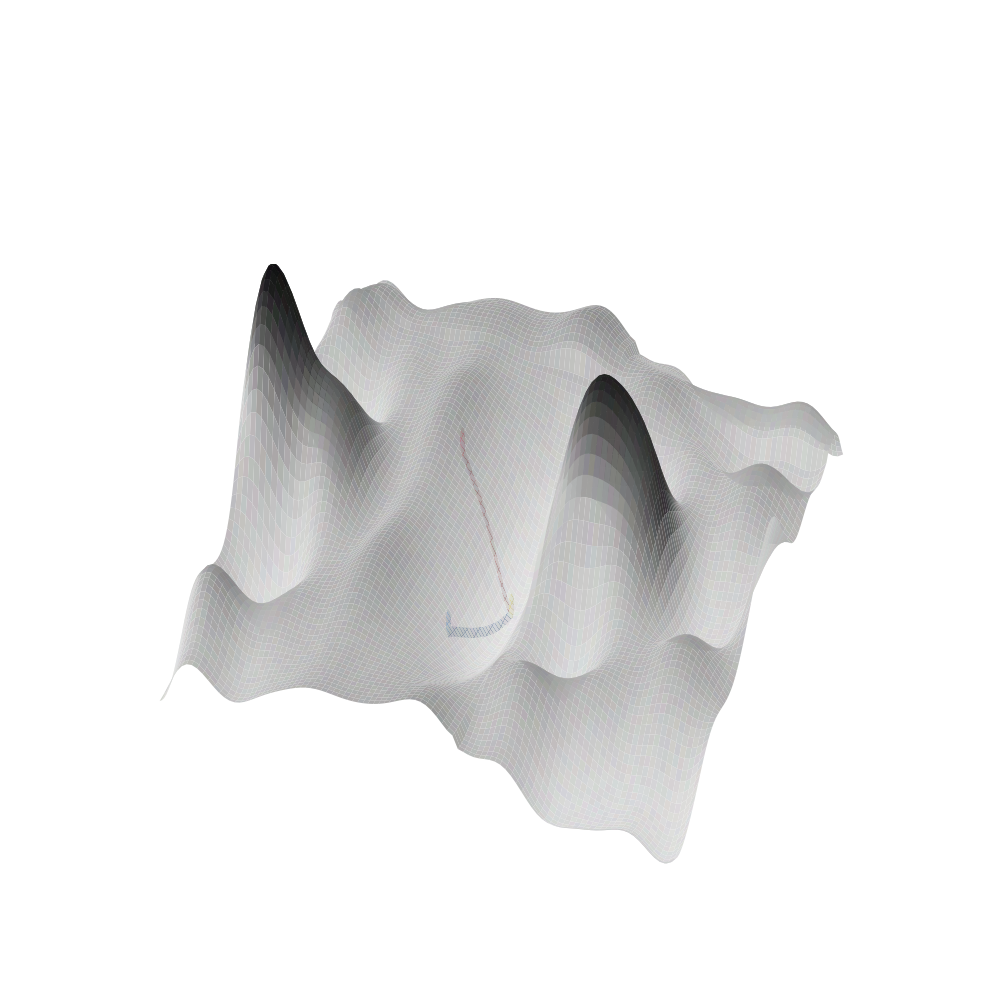

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.interpolate import RegularGridInterpolator

# =========================================
# 1. Setup Grid
# =========================================
N = 100
x = np.arange(1, N + 1)
y = np.arange(1, N + 1)
x, y = np.meshgrid(x, y)

np.random.seed(42)

# =========================================
# 2. Generate Energy Landscape
# =========================================
noise1 = 2 * np.random.rand(1, N)
noise2 = 2 * np.random.rand(1, N)

z_raw = ((np.sin(5*x/N) + 1) * (np.cos(15*y/N) - 1) + noise1) * \
        ((np.cos(5*y/N) - 1) * (np.sin(15*x/N) + 1) + noise2)

# =========================================
# 3. FFT Low-Pass Filter (Smooth Landscape)
# =========================================
zz = np.fft.fft2(z_raw)
zzz = np.zeros_like(zz)

n = 8
zzz[:n, :n] = zz[:n, :n]
zzz[-n:, :n] = zz[-n:, :n]
zzz[:n, -n:] = zz[:n, -n:]
zzz[-n:, -n:] = zz[-n:, -n:]

z_filtered = np.real(np.fft.ifft2(zzz))
z_filtered = gaussian_filter(z_filtered, sigma=1.3)

# =========================================
# 4. MOVE GLOBAL MINIMUM TO GRID CENTER
# =========================================
min_idx = np.unravel_index(np.argmin(z_filtered), z_filtered.shape)

center = (N // 2, N // 2)
shift_i = center[0] - min_idx[0]
shift_j = center[1] - min_idx[1]

z_centered = np.roll(z_filtered, shift=(shift_i, shift_j), axis=(0, 1))

# Rebuild centered coordinate system
x_centered = x - x[center]
y_centered = y - y[center]

# Shift energy zero
z_shift = z_centered - z_centered.min()
z_span = z_shift.max() - z_shift.min()

# =========================================
# 5. Initial Guess States (unchanged offsets)
# =========================================
idx_good = (center[0] - 20, center[1] - 5)
idx_bad  = (center[0] + 12, center[1] - 14)

xg, yg, zg = x_centered[idx_good], y_centered[idx_good], z_shift[idx_good]
xb, yb, zb = x_centered[idx_bad],  y_centered[idx_bad],  z_shift[idx_bad]

# =========================================
# 6. Continuous Interpolator
# =========================================
interp = RegularGridInterpolator(
    (y_centered[:, 0], x_centered[0]),
    z_shift,
    bounds_error=False,
    fill_value=None
)

# =========================================
# 7. Smooth Convergence Paths
# =========================================
def smooth_path(x0, y0, curvature, npts=220):
    t = np.linspace(0, 1, npts)

    cx = (1 - t) * x0 + curvature * np.sin(np.pi * t)
    cy = (1 - t) * y0 - curvature * np.sin(np.pi * t)

    pts = np.vstack([cy, cx]).T
    cz = interp(pts)
    cz = gaussian_filter1d(cz, sigma=6)

    return cx, cy, cz

path_good = smooth_path(xg, yg, curvature=0.15)
path_bad  = smooth_path(xb, yb, curvature=0.45)

# =========================================
# 7b. 3D mesh helpers: metallic spheres and tubes (on-top of surface)
# =========================================
def _hex_to_rgb(hex_color):
    h = hex_color.lstrip('#')
    return np.array([int(h[i:i+2], 16) / 255.0 for i in (0, 2, 4)])

def _metallic_shade(normals, base_rgb, light_dir, view_dir=None, ambient=0.35, diffuse_strength=0.5, specular_strength=0.45, shininess=32):
    """Compute metallic-style face colors: base + diffuse + strong specular highlight."""
    if normals.ndim == 2:
        # (n, 3) normals
        N = normals.reshape(-1, 3)
    else:
        N = normals.reshape(-1, 3)
    N = N / (np.linalg.norm(N, axis=1, keepdims=True) + 1e-9)
    L = np.array(light_dir, dtype=float)
    L = L / np.linalg.norm(L)
    if view_dir is None:
        V = np.array([0.5, 0.5, 1.0])  # roughly toward viewer
    else:
        V = np.array(view_dir, dtype=float)
    V = V / np.linalg.norm(V)
    H = (L + V) / 2
    H = H / (np.linalg.norm(H) + 1e-9)
    diff = np.maximum(0, (N @ L))
    spec = np.maximum(0, (N @ H)) ** shininess
    intensity = ambient + diffuse_strength * diff
    rgb = base_rgb * intensity[:, np.newaxis] + specular_strength * spec[:, np.newaxis]
    return np.clip(rgb, 0, 1)

def draw_sphere(ax, cx, cy, cz, radius, color, light_dir, resolution=24):
    """Draw a 3D metallic sphere at (cx, cy, cz) resting on-top of the surface."""
    u = np.linspace(0, 2 * np.pi, resolution)
    v = np.linspace(0, np.pi, resolution)
    x = radius * np.outer(np.cos(u), np.sin(v)) + cx
    y = radius * np.outer(np.sin(u), np.sin(v)) + cy
    z = radius * np.outer(np.ones_like(u), np.cos(v)) + cz
    # Outward normals (unit vector from center to vertex)
    nx = (x - cx) / (radius + 1e-12)
    ny = (y - cy) / (radius + 1e-12)
    nz = (z - cz) / (radius + 1e-12)
    base_rgb = _hex_to_rgb(color) if isinstance(color, str) and color.startswith('#') else plt.cm.colors.to_rgb(color)
    rgb = _metallic_shade(np.stack([nx, ny, nz], axis=-1), base_rgb, light_dir)
    facecolors = rgb.reshape(resolution, resolution, 3)
    ax.plot_surface(x, y, z, facecolors=facecolors, linewidth=0, antialiased=True, shade=False, alpha=0.98)

def draw_cylinder_between(ax, p1, p2, radius, color, light_dir, resolution=12):
    """Draw a 3D metallic cylinder between p1 and p2, sitting on-top of the surface."""
    p1, p2 = np.array(p1), np.array(p2)
    d = p2 - p1
    L = np.linalg.norm(d)
    if L < 1e-12:
        return
    z_axis = np.array([0.0, 0.0, 1.0])
    d_norm = d / L
    theta = np.linspace(0, 2 * np.pi, resolution)
    z_cyl = np.linspace(0, L, 2)
    Theta, Z_cyl = np.meshgrid(theta, z_cyl)
    X_cyl = radius * np.cos(Theta)
    Y_cyl = radius * np.sin(Theta)
    # Lateral normals (radial, no z component)
    Nx_cyl = np.cos(Theta)
    Ny_cyl = np.sin(Theta)
    Nz_cyl = np.zeros_like(Theta)
    cross = np.cross(z_axis, d_norm)
    if np.linalg.norm(cross) < 1e-12:
        axis = np.array([1.0, 0.0, 0.0]) if abs(d_norm[2]) < 0.99 else np.array([0.0, 1.0, 0.0])
    else:
        axis = cross / np.linalg.norm(cross)
    angle = np.arccos(np.clip(np.dot(z_axis, d_norm), -1.0, 1.0))
    def rot(v):
        return (v * np.cos(angle) + np.cross(v, axis) * (-np.sin(angle)) +
                np.outer(np.dot(v, axis), axis) * (1 - np.cos(angle)))
    verts = np.stack([X_cyl.ravel(), Y_cyl.ravel(), Z_cyl.ravel()], axis=1)
    norms = np.stack([Nx_cyl.ravel(), Ny_cyl.ravel(), Nz_cyl.ravel()], axis=1)
    X_rot = rot(verts)[:, 0].reshape(X_cyl.shape)
    Y_rot = rot(verts)[:, 1].reshape(Y_cyl.shape)
    Z_rot = rot(verts)[:, 2].reshape(Z_cyl.shape)
    N_rot = np.stack([rot(norms)[:, 0], rot(norms)[:, 1], rot(norms)[:, 2]], axis=1)
    base_rgb = _hex_to_rgb(color) if isinstance(color, str) and color.startswith('#') else plt.cm.colors.to_rgb(color)
    rgb = _metallic_shade(N_rot, base_rgb, light_dir)
    facecolors = rgb.reshape(2, resolution, 3)
    ax.plot_surface(X_rot + p1[0], Y_rot + p1[1], Z_rot + p1[2],
                    facecolors=facecolors, linewidth=0, antialiased=True, shade=False, alpha=0.98)

def draw_tube_along_path(ax, path_x, path_y, path_z, radius, color, light_dir, resolution=10, max_segments=50):
    """Draw a 3D metallic tube along a path. Subsampled for speed."""
    n = len(path_x)
    step = max(1, (n - 1) // max_segments)
    idx = np.arange(0, n, step)
    if idx[-1] != n - 1:
        idx = np.r_[idx, n - 1]
    for i in range(len(idx) - 1):
        i1, i2 = idx[i], idx[i + 1]
        p1 = (path_x[i1], path_y[i1], path_z[i1])
        p2 = (path_x[i2], path_y[i2], path_z[i2])
        draw_cylinder_between(ax, p1, p2, radius, color, light_dir, resolution=resolution)

# =========================================
# 8. Plot — Dark metallic surface + red/yellow/blue path
# =========================================
fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('white')
ax = fig.add_subplot(111, projection='3d')

# Dark metallic: light from upper-left, strong specular highlights (overlay)
ls = LightSource(azdeg=315, altdeg=35)
rgb = ls.shade(
    z_shift,
    cmap=plt.cm.Greys,
    vert_exag=0.22,
    blend_mode='overlay'
)
# Dark base with bright highlights for metallic sheen
rgb = np.clip(rgb * 0.82 + 0.06, 0, 1)
# Subtle brushed-metal variation (fine striations)
np.random.seed(1)
rgb = np.clip(rgb + 0.03 * (np.random.rand(*rgb.shape) - 0.5), 0, 1)

ax.plot_surface(
    x_centered, y_centered, z_shift,
    facecolors=rgb,
    rstride=1, cstride=1,
    alpha=0.95,
    linewidth=0,
    antialiased=True,
    shade=False
)

# Contour lines as subtle light ridges on the dark surface
ax.contour(
    x_centered, y_centered, z_shift,
    levels=15, colors='white',
    alpha=0.25, linewidths=0.6,
    zdir='z', offset=0
)

# Light direction (upper-left, same as surface) for metallic spheres and tubes
az_rad = np.radians(315)
alt_rad = np.radians(35)
light_dir = (np.cos(az_rad) * np.cos(alt_rad), np.sin(az_rad) * np.cos(alt_rad), np.sin(alt_rad))

# =========================================
# 9. Path: 3D metallic tubes and spheres — clearly ON TOP of surface
# =========================================
sphere_radius = 0.048 * z_span
tube_radius = 0.02 * z_span
# Tubes sit on top: centerline at surface + tube_radius
path_lift = tube_radius
path_red = path_bad
path_blue = (path_good[0][::-1], path_good[1][::-1], path_good[2][::-1])

path_red_z = path_red[2] + path_lift
draw_tube_along_path(ax, path_red[0], path_red[1], path_red_z, tube_radius, '#cc0000', light_dir, resolution=12)

path_blue_z = path_blue[2] + path_lift
draw_tube_along_path(ax, path_blue[0], path_blue[1], path_blue_z, tube_radius, '#0044aa', light_dir, resolution=12)

# Three metallic spheres resting on top (center = surface_z + sphere_radius)
draw_sphere(ax, xb, yb, zb + sphere_radius, sphere_radius, '#ff0033', light_dir)
draw_sphere(ax, 0, 0, sphere_radius, sphere_radius, '#ffdd00', light_dir)
draw_sphere(ax, xg, yg, zg + sphere_radius, sphere_radius, '#0080ff', light_dir)

# =========================================
# 10. View — upper-left lighting, white background
# =========================================
ax.set_facecolor('white')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.view_init(elev=50, azim=-70)
ax.set_axis_off()

plt.tight_layout()
plt.show()